# Домашнє завдання: Побудова класифікатора сентименту на основі набору даних Tweet Sentiment Extraction

**Мета:** Провести аналіз набору даних, виконати векторизацію текстових даних за допомогою методів bag-of-words та TF-IDF, порівняти їх, побудувати класифікатор та провести аналіз помилок.

**Набір даних:**
Дані беремо з цього змагання на Kaggle: https://www.kaggle.com/competitions/tweet-sentiment-extraction/data?select=train.csv


Якщо не вдається завантажиит з Kaggle, ось тут можна - https://drive.google.com/file/d/1kfu5zCRsDHxoBZigBlGIcCieKlws02HT/view?usp=sharing

Оригінальне змагання має дещо іншу задачу, але ми будемо поки будувати саме класифікатор.

Увага! В цьому наборі завдань для простоти експериментів ми будемо спочатку робити векторизацію на всьому наборі даних, а потім розбивку на train i test. В робочих проєктах ми теж можемо використати цей підхід для швидшої побудови PoC (proof of concept). Але фінальне рішення, яке ми будемо деплоїти - треба проводити за правилом - спочатку розбивка на трейн і тест, потім пишемо обробку для трейну, навчаємо векторизатори. І потім використовуємо готові векторизатори для тесту і всіх даних на етапі передбачення (інференсу).

### Завдання 1. Завантаження та ознайомлення з набором даних

- Завантажте набір даних `train.csv` з посилання та ознайомтеся з його структурою.
- Виведіть перші 5 рядків та основну статистику: кількість записів, типи колонок, кількість пропущених значень.
- Видаліть записи, в яких є пропущені значення.



In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem.snowball import SnowballStemmer
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

In [5]:
train_fname = 'tweet_sentiment_train.csv.zip'
raw_df = pd.read_csv(train_fname)

In [6]:
raw_df.head(5)

,textID,text,selected_text,sentiment
0,cb774db0d1,"I`d have responded, if I were going","I`d have responded, if I were going",neutral
1,549e992a42,Sooo SAD I will miss you here in San Diego!!!,Sooo SAD,negative
2,088c60f138,my boss is bullying me...,bullying me,negative
3,9642c003ef,what interview! leave me alone,leave me alone,negative
4,358bd9e861,"Sons of ****, why couldn`t they put them on t...","Sons of ****,",negative


In [7]:
raw_df.shape

(27481, 4)

In [8]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [9]:
raw_df[raw_df.isna().any(axis=1)]

,textID,text,selected_text,sentiment
314,fdb77c3752,NaN,NaN,neutral


In [10]:
raw_df = raw_df.dropna().reset_index(drop=True)

### Завдання 2. Exploratory Data Analysis

- Проведіть аналіз кількості класів та розподілу міток. Класи знаходяться в колонці `sentiment`.
- Візуалізуйте розподіл довжин текстів в символах та зробіть висновок про довжини постів: якої довжини постів найбільше, що бачите з розподілу?



In [11]:
raw_df.sentiment.value_counts(normalize=True)

sentiment
neutral     0.404549
positive    0.312300
negative    0.283151
Name: proportion, dtype: float64

In [12]:
raw_df['text_length'] = raw_df['text'].str.len()

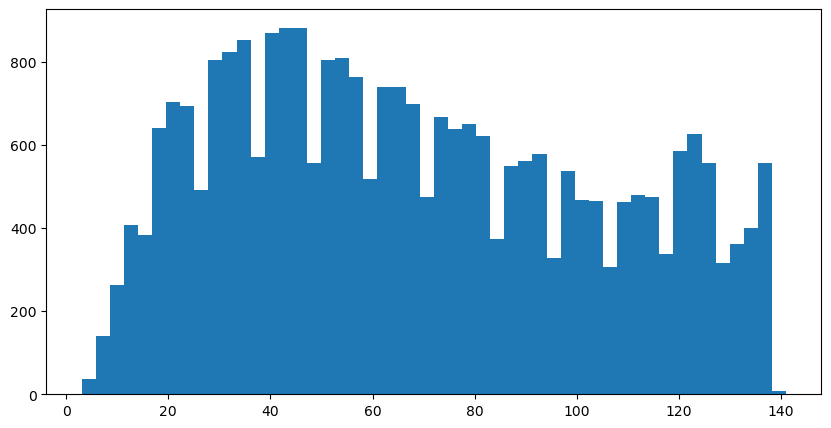

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(raw_df['text_length'], bins=50)
plt.show()

Розподіл довжини тексту досить різноманітний. Але набільше твіт постів мають довжину десь 20-60 символів

### Завдання 3. Попередня обробка текстових даних та векторизація з bag of words


Наша задача тут отримати вектори методом bag of words колонки `text`, виконавши попередню обробку тексту.
Попередня обробка має включати
- видалення stopwords необхідної мови
- токенізація (розбиття текстів на фрагменти по 1 слову)
- стеммінг слів зі `SnowballStemmer`.
- самостійно задайте кількість слів в словнику для `sklearn.feature_extraction.text.CountVectorizer`. Можливо для цього доведеться виконати додатковий аналіз.

Ви також можете додати сюди додаткові методи очистки текстів, наприклад, видалення деяких символів чи груп символів, якщо в процесі роботи побачите, що хочете щось видалити.

Напишіть код аби виконати це завдання. Перед цим рекомендую детально ознайомитись з тим, що робить обʼєкт `sklearn.feature_extraction.text.CountVectorizer` за замовченням.

Це завдання можна виконати двома способами - один - максимально подібно до того, як ми це робили в лекції, другий - дещо інакше перегрупувавши етапи обробки тексту.




In [14]:
nltk.download('stopwords')
english_stopwords = stopwords.words('english')


nltk.download('wordnet')
nltk.download('omw-1.4')
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Тут я вирішила додати лематизацію для ступенів порівняння прикметників та фори неправиьних дієслів

In [15]:
def normalize(word):
    lemma = lemmatizer.lemmatize(word, wordnet.ADJ)   
    if lemma != word:
        return lemma
    return lemmatizer.lemmatize(word, wordnet.VERB)

І створила словник із сленговими скороченнями в англійській, щоб стоп-слова співпали з ними і видалилися

In [16]:
SLANG_MAP = {
    'u': 'you', 'ur': 'your', 'im': 'i am',
    'dont': 'do not', 'cant': 'can not', 'wont': 'will not',
    'isnt': 'is not', 'arent': 'are not', 'wasnt': 'was not', 'werent': 'were not',
    'havent': 'have not', 'hasnt': 'has not', 'hadnt': 'had not',
    'didnt': 'did not', 'doesnt': 'does not', 
    'wouldnt': 'would not', 'couldnt': 'could not', 'shouldnt': 'should not', 
}

In [17]:
def tokenize(text):
    text = text.replace('gonna', 'going to').replace('wanna', 'want to')
    tokens = word_tokenize(text)

    expanded = []
    for tok in tokens:
        expanded.extend(SLANG_MAP.get(tok, tok).split())

    normalized = [normalize(w) for w in expanded]
    return [stemmer.stem(w) for w in normalized]

In [18]:
stemmer = SnowballStemmer(language='english')

vectorizer = CountVectorizer(lowercase=True,
                              tokenizer=tokenize,
                              stop_words=english_stopwords,
                              max_features=300)

In [19]:
vectorizer.fit(raw_df.text)

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'win', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


CountVectorizer(max_features=300,
                stop_words=['a', 'about', 'above', 'after', 'again', 'against',
                            'ain', 'all', 'am', 'an', 'and', 'any', 'are',
                            'aren', "aren't", 'as', 'at', 'be', 'because',
                            'been', 'before', 'being', 'below', 'between',
                            'both', 'but', 'by', 'can', 'couldn', "couldn't", ...],
                tokenizer=<function tokenize at 0x00000227E7632A60>)

In [20]:
vectorizer.get_feature_names_out()

array(['!', '#', '$', '&', "'", '(', ')', '*', ',', '-', '.', '..', '...',
       '....', '.....', '1', '2', '3', '4', '5', ':', ';', '<', '=', '?',
       '@', '`', 'actual', 'almost', 'alreadi', 'also', 'alway', 'amaz',
       'ani', 'anoth', 'anyon', 'anyth', 'around', 'ask', 'away',
       'awesom', 'aww', 'babi', 'back', 'bad', 'beauti', 'becaus', 'bed',
       'befor', 'believ', 'best', 'big', 'birthday', 'bite', 'book',
       'bore', 'boy', 'break', 'busi', 'buy', 'call', 'car', 'caus',
       'chang', 'check', 'class', 'clean', 'close', 'coffe', 'cold',
       'come', 'cool', 'could', 'cri', 'cute', 'day', 'die', 'dinner',
       'drink', 'drive', 'earli', 'eat', 'end', 'enjoy', 'even', 'ever',
       'everyon', 'everyth', 'exam', 'excit', 'famili', 'far', 'feel',
       'final', 'find', 'finish', 'first', 'follow', 'food', 'forget',
       'forward', 'friday', 'friend', 'fun', 'funni', 'game', 'get',
       'girl', 'give', 'glad', 'go', 'god', 'good', 'great', 'guess',
      

In [21]:
X_bow = vectorizer.transform(raw_df.text)
X_bow.shape

(27480, 300)

### Завдання 4. Побудова класифікатора

- Розділіть індекси даних на навчальний та тестовий набори в обраному співвівдношенні. Використовуючи отримані індекси сфомуйте набори для тренування класифікатора `X_train_bow, X_test_bow, y_train, y_test`.
- Навчіть класифікатор (наприклад, Logistic Regression, Decision Tree або один з алгоритмів бустингу) на даних, векторизованих методом bag-of-words. Спробуйте кілька моделей і оберіть найбільш точну :)
- Виведіть інформацію, яка дає можливість оцінити якість класифікації.
- Оцініть якість фінальної класифікації: вона хороша чи не дуже?



In [22]:
train_idx, test_idx = train_test_split(
    raw_df.index,
    test_size=0.2,
    random_state=42,
    stratify=raw_df.sentiment
)

X_train_bow = X_bow[train_idx]
X_test_bow = X_bow[test_idx]
y_train = raw_df.sentiment.loc[train_idx]
y_test = raw_df.sentiment.loc[test_idx]

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train_bow, y_train)
    preds = model.predict(X_test_bow)
    print(name)
    print(classification_report(y_test, preds))
    print('-' * 50)

Logistic Regression
              precision    recall  f1-score   support

    negative       0.71      0.52      0.60      1556
     neutral       0.60      0.77      0.67      2223
    positive       0.77      0.68      0.72      1717

    accuracy                           0.67      5496
   macro avg       0.69      0.65      0.66      5496
weighted avg       0.68      0.67      0.67      5496

--------------------------------------------------
Decision Tree
              precision    recall  f1-score   support

    negative       0.52      0.56      0.54      1556
     neutral       0.57      0.56      0.57      2223
    positive       0.65      0.62      0.63      1717

    accuracy                           0.58      5496
   macro avg       0.58      0.58      0.58      5496
weighted avg       0.58      0.58      0.58      5496

--------------------------------------------------
Gradient Boosting
              precision    recall  f1-score   support

    negative       0.75      

Найкраща Logistic Regression , трохи краща за Gradient Boosting і помітно краща за Decision Tree. Але якість все ж середня: модель найгірше розпізнає negative твіти, часто плутаючи їх з neutral через дисбаланс класів 

### Завдання 5. Аналіз впливовості слів в отриманого класифікатора

- Для обраної вами моделі проведіть аналіз важливості слів (ознак): які слова (токени) найбільше впливають для визначення сентименту? Чи це логічно на ваш погляд, що саме ці символи впливають найбільше/найменще?


In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_bow, y_train)

LogisticRegression(max_iter=1000)

In [25]:
model.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [26]:
feature_importance_negative = pd.Series(model.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_negative[:10]

sad       2.390292
suck      2.235279
sorri     2.068291
bore      2.059617
hate      1.996795
stupid    1.959176
poor      1.807187
hurt      1.786492
sick      1.777157
miss      1.724125
Name: imp, dtype: float64

Для негативного класу ці коефіцієнти мейк сенс)

In [27]:
feature_importance_neutral = pd.Series(model.coef_[1], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_neutral[:10]

close     0.487429
tho       0.485241
star      0.406566
send      0.377670
=         0.370180
clean     0.326251
hey       0.319484
lol       0.301976
friday    0.295879
soon      0.295204
Name: imp, dtype: float64

Для мене ці слова виглядають нейтральними

In [28]:
feature_importance_positive = pd.Series(model.coef_[2], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_positive[:10]

awesom    2.407187
thank     2.306738
glad      2.185909
cute      2.177261
amaz      2.085833
love      2.018007
nice      1.847164
enjoy     1.846169
happi     1.742927
welcom    1.690276
Name: imp, dtype: float64

І тут слова мають позитивний вайб

### Завдання 6. Векторизація текстів з допомогою TF-IDF. Тренування класифікатора, аналіз точності і впливовості слів.

- Проведіть векторизацію текстів з векторизатором TfidfVectorizer. Реалізуйте векторизацію так, аби препроцесинг включав всі ті самі кроки, що і в випадку використання векторизації Bag of Words.

- Натренуйте той самий класифікатор на TF-IDF векторах, виконавши розбивку набору даних на train, test так, аби в трейні були всі ті самі записи, що і були в попередньому завданні (це важливо для порівняння результатів).

- Проаналізуйте якість класифікації вивівши потрібні для цього метрики. Чи стала якість класифікації кращою?

- Які токени найбільше впливають на результат при тренуваннні класифікатора з TF-IDF векторами? Порівняйте з найважливішими токенами при Bag of Words векторизації. Яку векторизацію ви б обрали для фінальної імплементації рішення? Обґрунтуйте свій вибір.



In [29]:
tfidf_vectorizer = TfidfVectorizer(lowercase=True,
                                    tokenizer=tokenize,
                                    stop_words=english_stopwords,
                                    max_features=300)

X_tfidf = tfidf_vectorizer.fit_transform(raw_df.text)

C:\Users\Admin\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
C:\Users\Admin\anaconda3\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ["'d", "'m", "'s", 'abov', 'ani', 'becaus', 'befor', 'could', 'dure', 'might', 'must', "n't", 'need', 'onc', 'onli', 'ourselv', 'sha', 'themselv', 'veri', 'whi', 'win', 'wo', 'would', 'yourselv'] not in stop_words.
  warnings.warn(


In [30]:
X_train_tfidf = X_tfidf[train_idx]
X_test_tfidf = X_tfidf[test_idx]

In [31]:
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train_tfidf, y_train)

preds_tfidf = tfidf_model.predict(X_test_tfidf)
print(classification_report(y_test, preds_tfidf))

              precision    recall  f1-score   support

    negative       0.69      0.53      0.60      1556
     neutral       0.60      0.75      0.67      2223
    positive       0.77      0.68      0.72      1717

    accuracy                           0.67      5496
   macro avg       0.69      0.65      0.66      5496
weighted avg       0.68      0.67      0.67      5496



Якість моделі майже не змінилася

In [32]:
tfidf_model.classes_

array(['negative', 'neutral', 'positive'], dtype=object)

In [33]:
feature_importance_negative = pd.Series(tfidf_model.coef_[0], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_negative[:10]

sad       4.393637
sorri     3.828240
miss      3.723280
suck      3.713155
hate      3.433004
bore      3.335921
stupid    3.184510
sick      3.041274
hurt      2.986690
bad       2.908629
Name: imp, dtype: float64

In [34]:
feature_importance_neutral = pd.Series(tfidf_model.coef_[1], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_neutral[:10]

tho      0.665320
?        0.642355
send     0.564618
close    0.549481
lol      0.537026
morn     0.455163
=        0.417150
play     0.412519
clean    0.404105
yeah     0.389686
Name: imp, dtype: float64

In [35]:
feature_importance_positive = pd.Series(tfidf_model.coef_[2], index=vectorizer.get_feature_names_out(), name='imp').sort_values(ascending=False)
feature_importance_positive[:10]

love      4.910524
thank     4.748460
awesom    4.268098
happi     3.674620
great     3.531026
amaz      3.458872
nice      3.433711
glad      3.381257
cute      3.379836
hope      3.359813
Name: imp, dtype: float64

Тут навіть токени впливі у моделей майже збігаються, відрізняються лише порядком. тому конкретно для цих даних я б використала одну з двох, оскільки результат фактично ідентичний

### Завдання 7. Аналіз помилок класифікації з векторизацією TF-IDF.

- Проаналізуйте, на яких екземплярах помиляється класифікатор при векторизації TF-IDF.
- На основі аналізу запропонуйте 3 шляхи поліпшення якості класифікації.

In [36]:
inputs = tfidf_vectorizer.transform(raw_df.text)

In [37]:
raw_df['prediction'] = tfidf_model.predict(inputs)

In [38]:
raw_df['error'] = raw_df.sentiment != raw_df['prediction']

In [44]:
raw_df[raw_df.error & (raw_df.prediction=="negative")][['text', 'sentiment', 'prediction']][:20]

,text,sentiment,prediction
24,SEe waT I Mean bOuT FoLL0w fRiiDaYs... It`S cA...,neutral,negative
43,RATT ROCKED NASHVILLE TONITE..ONE THING SUCKED...,neutral,negative
50,Then you should check out http://twittersucks...,neutral,negative
51,"also bored at school, its my third freelesson...",neutral,negative
119,"I hate Fallout 3 it keeps making me jump, I`m ...",neutral,negative
120,"I had it! On my itunes, but then I lost all m...",neutral,negative
149,She`s unassuming and unpretentious. She`s jus...,positive,negative
173,i think iv hurt my tooth and eilish and cassi...,neutral,negative
203,more nightmares? *huggles*,neutral,negative
213,We never miss ICarly - my son has a huge crus...,positive,negative


In [41]:
raw_df[raw_df.error & (raw_df.prediction=="neutral")][['text', 'sentiment', 'prediction']][:20]

,text,sentiment,prediction
2,my boss is bullying me...,negative,neutral
3,what interview! leave me alone,negative,neutral
12,My Sharpie is running DANGERously low on ink,negative,neutral
15,"Uh oh, I am sunburned",negative,neutral
21,Playing Ghost Online is really interesting. Th...,positive,neutral
27,On the way to Malaysia...no internet access to...,negative,neutral
29,Went to sleep and there is a power cut in Noid...,negative,neutral
30,I`m going home now. Have you seen my new twitt...,positive,neutral
38,i`m soooooo sleeeeepy!!! the last day o` schoo...,negative,neutral
46,egh blah and boooooooooooo i dunno wanna go to...,negative,neutral


In [42]:
raw_df[raw_df.error & (raw_df.prediction=="positive")][['text', 'sentiment', 'prediction']][:20]

,text,sentiment,prediction
5,http://www.dothebouncy.com/smf - some shameles...,neutral,positive
10,"as much as i love to be hopeful, i reckon the...",neutral,positive
20,"oh Marly, I`m so sorry!! I hope you find her...",neutral,positive
34,"Ahhh, I slept through the game. I`m gonna tr...",neutral,positive
40,"Car not happy, big big dent in boot! Hoping t...",neutral,positive
59,what fun are you speaking of?,neutral,positive
76,"WOW, i AM REALLY MiSSiN THE FAM(iLY) TODAY. BA...",negative,positive
103,i realy wanted to go out cause its so nice but...,negative,positive
106,cool i wear black most of the time when i go out,neutral,positive
139,"missed all the awesome weather, because she wa...",negative,positive


тут проблема, що через токенізацію і розділення усіх слів, модель сприймає тексти за позитивні через позитивні слова, навіть якщо передними було заперечне слово

шляхи поліпшення: робити так, щоб іноді фрази розпізнавалися як одна ознака; нормалізувати розтягнуте написання регулярним виразом перед токенізацією; і можливо існують методи, які враховують і порядок слів у тексті і контекст, це теж може бути корисно для покращення класифікації

І на фінал кернел для натхнення і ознайомлення з рішенням оригінальної задачі. Багато цікавих візуалізацій і аналізу є тут, а також тут розвʼязується саме проблема named entitty recognition і можна ознайомитись як це робиться - вона дещо складніша по своїй суті ніж класифікація, подумайте, чому:

https://www.kaggle.com/code/tanulsingh077/twitter-sentiment-extaction-analysis-eda-and-model